In [1]:
# see data structure
with open('All_external.csv') as f:
    i = 0
    while i < 10:
        print(f.readline())
        i += 1

Date,Article_title,Stock_symbol,Url,Publisher,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary

2020-06-05 06:30:54 UTC,Stocks That Hit 52-Week Highs On Friday,A,https://www.benzinga.com/news/20/06/16190091/stocks-that-hit-52-week-highs-on-friday,Benzinga Insights,,,,,,

2020-06-03 06:45:20 UTC,Stocks That Hit 52-Week Highs On Wednesday,A,https://www.benzinga.com/news/20/06/16170189/stocks-that-hit-52-week-highs-on-wednesday,Benzinga Insights,,,,,,

2020-05-26 00:30:07 UTC,71 Biggest Movers From Friday,A,https://www.benzinga.com/news/20/05/16103463/71-biggest-movers-from-friday,Lisa Levin,,,,,,

2020-05-22 08:45:06 UTC,46 Stocks Moving In Friday's Mid-Day Session,A,https://www.benzinga.com/news/20/05/16095921/46-stocks-moving-in-fridays-mid-day-session,Lisa Levin,,,,,,

2020-05-22 07:38:59 UTC,"B of A Securities Maintains Neutral on Agilent Technologies, Raises Price Target to $88",A,https://www.benzinga.com/news/20/05/16095304/b-of-a-securities-maintains-neutra

In [8]:
import pandas as pd

news = pd.read_csv('All_external.csv', nrows=100000)
news.info()
# news.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              100000 non-null  object 
 1   Article_title     100000 non-null  object 
 2   Stock_symbol      100000 non-null  object 
 3   Url               100000 non-null  object 
 4   Publisher         100000 non-null  object 
 5   Author            0 non-null       float64
 6   Article           0 non-null       float64
 7   Lsa_summary       0 non-null       float64
 8   Luhn_summary      0 non-null       float64
 9   Textrank_summary  0 non-null       float64
 10  Lexrank_summary   0 non-null       float64
dtypes: float64(6), object(5)
memory usage: 8.4+ MB


,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary
count,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
import pandas as pd

file_path = 'All_external.csv'
chunk_size = 100000 
limit = 1000000 # Total rows we want to stop at

total_rows = 0
unique_tickers = set()
min_date_str = None
max_date_str = None
null_counts = {}

essential_cols = ['Date', 'Stock_symbol']

print(f"Starting scan of the first {limit} rows...")

# 1. We use the same read_csv with chunksize
for chunk in pd.read_csv(file_path, usecols=essential_cols, chunksize=chunk_size):
    
    # 2. Update stats for the current chunk
    total_rows += len(chunk)
    unique_stock.update(chunk['Stock_symbol'].dropna().unique())
    
    temp_min = chunk['Date'].min()
    temp_max = chunk['Date'].max()
    
    if min_date_str is None or temp_min < min_date_str:
        min_date_str = temp_min
    if max_date_str is None or temp_max > max_date_str:
        max_date_str = temp_max
        
    for col in essential_cols:
        null_counts[col] = null_counts.get(col, 0) + chunk[col].isnull().sum()

    # 3. CHECK THE LIMIT: If we hit 1 million, stop the loop
    if total_rows >= limit:
        print(f"Reached {total_rows} rows. Stopping scan.")
        break

print(f"\n--- Statistics for the first {total_rows} rows ---")
print(f"Unique Stocks found: {len(unique_tickers)}")
print(f"Date Range: {min_date_str} to {max_date_str}")
print(f"Missing Values: {null_counts}")

Starting scan of the first 1000000 rows...
Reached 1000000 rows. Stopping scan.

--- Statistics for the first 1000000 rows ---
Unique Stocks found: 4314
Date Range: 2009-02-14 00:00:00 UTC to 2020-06-11 13:11:20 UTC
Missing Values: {'Date': np.int64(0), 'Stock_symbol': np.int64(0)}


Trying to load the last rows(but would be very slow, cuz got to loop over the rows that want to skip)

In [20]:
file_path = 'All_external.csv'
chunk_size = 100000 
limit = 1000000 
# rows_to_skip = 14700000
rows_to_skip = 5000000

# FIX: You MUST define the column names because the header is being skipped
all_col_names = ['Date', 'Article_title', 'Stock_symbol', 'Url', 'Publisher', 
                 'Author', 'Article', 'Lsa', 'Luhn', 'Textrank', 'Lexrank']

total_rows = 0
unique_tickers = set()
min_date_str = None
max_date_str = None
null_counts = {}

# We still only load these two to keep it fast
essential_cols = ['Date', 'Stock_symbol']

print(f"Jumping to row {rows_to_skip} and scanning {limit} rows...")

# Added 'names=all_col_names' so Pandas knows what the columns are
for chunk in pd.read_csv(file_path, 
                         skiprows=rows_to_skip, 
                         nrows=limit, 
                         names=all_col_names, 
                         usecols=essential_cols, 
                         chunksize=chunk_size,
                         header=None): # Tell pandas there is no header in the data it's reading
    
    total_rows += len(chunk)
    unique_stock.update(chunk['Stock_symbol'].dropna().unique())
    
    temp_min = chunk['Date'].min()
    temp_max = chunk['Date'].max()
    
    if min_date_str is None or temp_min < min_date_str:
        min_date_str = temp_min
    if max_date_str is None or temp_max > max_date_str:
        max_date_str = temp_max
        
    for col in essential_cols:
        null_counts[col] = null_counts.get(col, 0) + chunk[col].isnull().sum()

    if total_rows >= limit:
        break

print(f"\n--- Statistics for the LAST {total_rows} rows ---")
print(f"Unique Stocks: {len(unique_tickers)}")
print(f"Date Range: {min_date_str} to {max_date_str}")
print(f"Missing Values: {null_counts}")

Jumping to row 5000000 and scanning 1000000 rows...


NameError: name 'unique_stock' is not defined

In [18]:
import pandas as pd

news = pd.read_csv('nasdaq_exteral_data.csv', nrows=100000)
news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        100000 non-null  float64
 1   Date              100000 non-null  object 
 2   Article_title     100000 non-null  object 
 3   Stock_symbol      100000 non-null  object 
 4   Url               100000 non-null  object 
 5   Publisher         0 non-null       float64
 6   Author            0 non-null       float64
 7   Article           100000 non-null  object 
 8   Lsa_summary       99999 non-null   object 
 9   Luhn_summary      100000 non-null  object 
 10  Textrank_summary  100000 non-null  object 
 11  Lexrank_summary   100000 non-null  object 
dtypes: float64(3), object(9)
memory usage: 9.2+ MB


In [53]:
import pandas as pd
import matplotlib.pyplot as plt

def save_metadata_table(data, filename):
    df = pd.DataFrame(data)
    
    # We use a wider figure because these tables have many columns
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis('off')
    
    the_table = ax.table(cellText=df.values, 
                         colLabels=df.columns, 
                         loc='center', 
                         cellLoc='left') # Left-aligned for text data
    
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(9)
    the_table.scale(1.1, 1.8)
    
    # IEEE Styling: Top and Bottom heavy lines
    for (row, col), cell in the_table.get_celld().items():
        cell.set_linewidth(0)
        if row == 0:
            cell.set_text_props(weight='bold')
            cell.visible_edges = 'T'
            cell.set_linewidth(1.5)
        elif row == len(df):
            cell.visible_edges = 'B'
            cell.set_linewidth(1.5)
        else:
            # Optional: very light horizontal lines for readability
            cell.visible_edges = 'B'
            cell.set_edgecolor('#F0F0F0')
            cell.set_linewidth(0.5)

    plt.savefig(filename, dpi=300, bbox_inches='tight', transparent=True)
    plt.close()
    print(f"Saved Metadata Table: {filename}")

# --- DATA FOR ALL_EXTERNAL.CSV ---
external_info = [
    {"#": 0, "Column": "Date", "Non-Null": "100,000", "Dtype": "object"},
    {"#": 1, "Column": "Article_title", "Non-Null": "100,000", "Dtype": "object"},
    {"#": 2, "Column": "Stock_symbol", "Non-Null": "100,000", "Dtype": "object"},
    {"#": 3, "Column": "Url", "Non-Null": "100,000", "Dtype": "object"},
    {"#": 4, "Column": "Publisher", "Non-Null": "100,000", "Dtype": "object"},
    {"#": 5, "Column": "Author", "Non-Null": "0", "Dtype": "float64"},
    {"#": 6, "Column": "Article", "Non-Null": "0", "Dtype": "float64"},
    {"#": 7, "Column": "Lsa_summary", "Non-Null": "0", "Dtype": "float64"},
    {"#": 8, "Column": "Luhn_summary", "Non-Null": "0", "Dtype": "float64"},
    {"#": 9, "Column": "Textrank_summary", "Non-Null": "0", "Dtype": "float64"},
    {"#": 10, "Column": "Lexrank_summary", "Non-Null": "0", "Dtype": "float64"},
]

# --- DATA FOR NASDAQ_EXTERNAL_DATA.CSV ---
nasdaq_info = [
    {"#": 0, "Column": "Unnamed: 0", "Non-Null": "100,000", "Dtype": "float64"},
    {"#": 1, "Column": "Date", "Non-Null": "100,000", "Dtype": "object"},
    {"#": 2, "Column": "Article_title", "Non-Null": "100,000", "Dtype": "object"},
    {"#": 3, "Column": "Stock_symbol", "Non-Null": "100,000", "Dtype": "object"},
    {"#": 4, "Column": "Url", "Non-Null": "100,000", "Dtype": "object"},
    {"#": 5, "Column": "Publisher", "Non-Null": "0", "Dtype": "float64"},
    {"#": 6, "Column": "Author", "Non-Null": "0", "Dtype": "float64"},
    {"#": 7, "Column": "Article", "Non-Null": "100,000", "Dtype": "object"},
    {"#": 8, "Column": "Lsa_summary", "Non-Null": "99,999", "Dtype": "object"},
    {"#": 9, "Column": "Luhn_summary", "Non-Null": "100,000", "Dtype": "object"},
    {"#": 10, "Column": "Textrank_summary", "Non-Null": "100,000", "Dtype": "object"},
    {"#": 11, "Column": "Lexrank_summary", "Non-Null": "100,000", "Dtype": "object"},
]

save_metadata_table(external_info, 'table_metadata_all_external.png')
save_metadata_table(nasdaq_info, 'table_metadata_nasdaq.png')

Saved Metadata Table: table_metadata_all_external.png
Saved Metadata Table: table_metadata_nasdaq.png


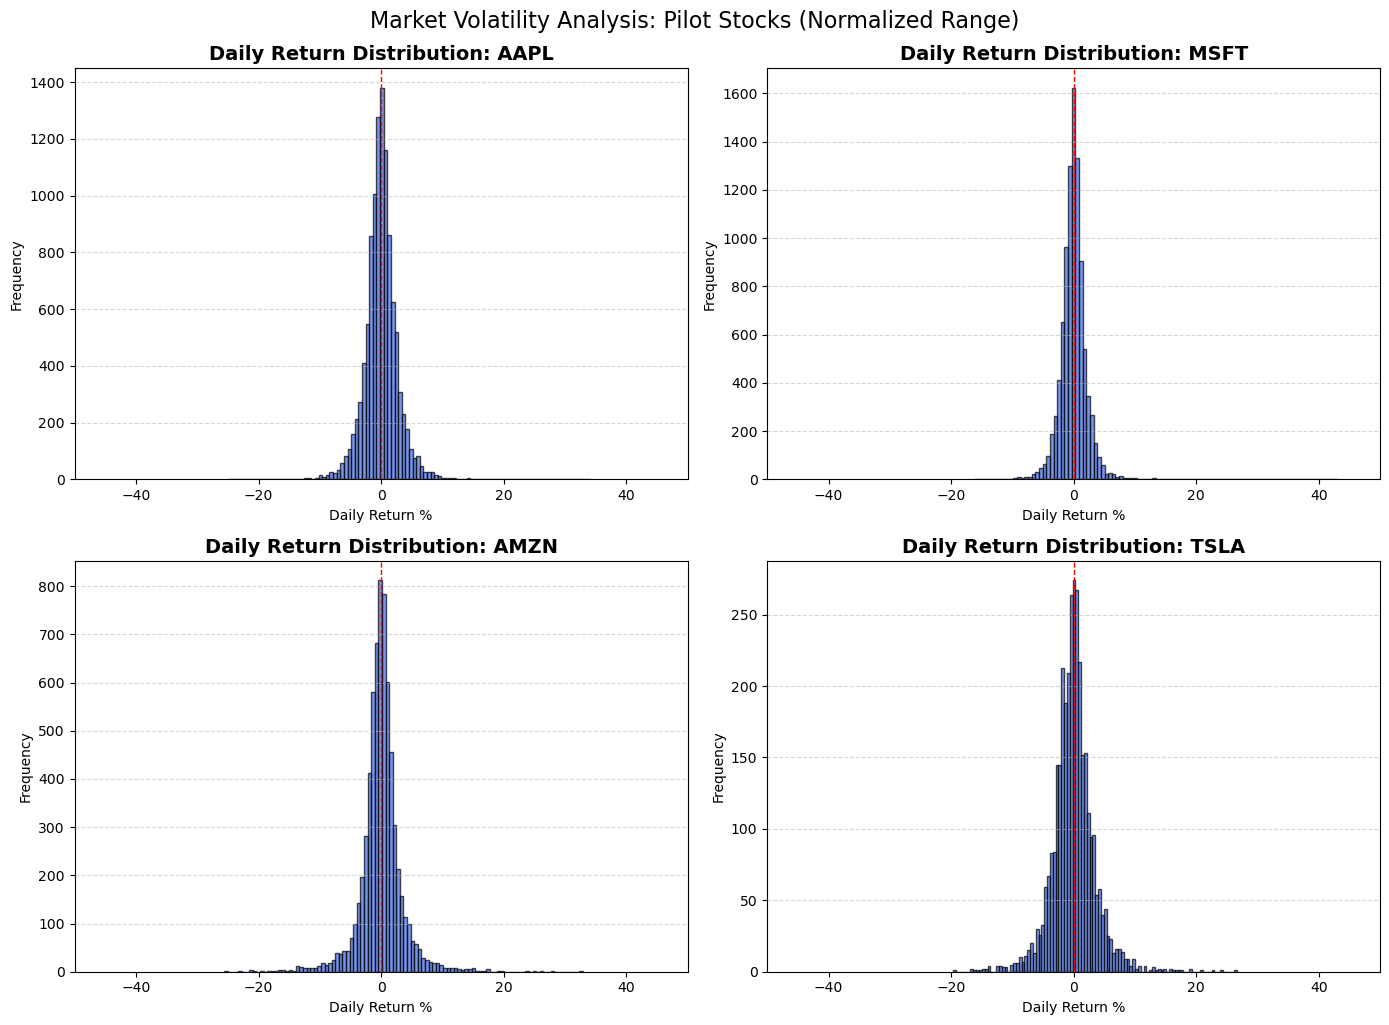

Process complete. Check 'stock_return_quadrants_final.png' for the result.


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Setup the list of tickers and the figure
tickers = ['AAPL', 'MSFT', 'AMZN', 'TSLA']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

# 2. Loop through each ticker to create the quadrants
for i, ticker in enumerate(tickers):
    # Adjust this path if your folder structure is slightly different
    file_path = fr'full_history\full_history\{ticker}.csv'
    
    try:
        # Load data
        df = pd.read_csv(file_path)
        
        # Standardize column names to lowercase (handles 'Adj Close' vs 'adj close')
        df.columns = [c.lower() for c in df.columns]
        
        # Calculate daily return percentage
        df['return'] = df['adj close'].pct_change() * 100
        
        # --- THE CRITICAL FIX ---
        # Filter the data to ONLY include returns between -10% and +10% 
        # This forces the 100 bins to be high-resolution in the visible area.
        tight_data = df['return'][(df['return'] > -50) & (df['return'] < 50)].dropna()
        
        ax = axes[i]
        
        # Plot the high-resolution histogram
        ax.hist(tight_data, bins=100, color='royalblue', edgecolor='black', alpha=0.7)
        
        # Set the x-axis limits to match our filter
        ax.set_xlim([-50, 50])
        
        # Styling and Labels
        ax.set_title(f'Daily Return Distribution: {ticker}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Daily Return %')
        ax.set_ylabel('Frequency')
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Add a vertical red line at 0% to show the "Mean"
        ax.axvline(0, color='red', linestyle='dashed', linewidth=1)
        
    except Exception as e:
        print(f"Error processing {ticker}: {e}")

# 3. Final formatting for the entire figure
plt.tight_layout()
plt.suptitle('Market Volatility Analysis: Pilot Stocks (Normalized Range)', fontsize=16, y=1.02)

# 4. Save and Show
plt.savefig('stock_return_quadrants_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("Process complete. Check 'stock_return_quadrants_final.png' for the result.")

In [40]:
import pandas as pd
import numpy as np

tickers = ['AAPL', 'MSFT', 'AMZN', 'TSLA']
stock_summary = []

for ticker in tickers:
    df_p = pd.read_csv(fr'full_history\full_history\{ticker}.csv')
    df_p.columns = [c.lower() for c in df_p.columns]
    df_p['return'] = df_p['adj close'].pct_change() * 100
    
    # Identify 'Black Swans' (Days with > 10% move)
    black_swans = len(df_p[df_p['return'].abs() > 10])
    
    stock_summary.append({
        'Ticker': ticker,
        'Total Days': len(df_p),
        'Avg Daily Return %': round(df_p['return'].mean(), 4),
        'Max Daily Gain %': round(df_p['return'].max(), 2),
        'Max Daily Loss %': round(df_p['return'].min(), 2),
        'Volatility (StdDev)': round(df_p['return'].std(), 2),
        'Black Swan Events': black_swans
    })

df_stock_features = pd.DataFrame(stock_summary)
print("--- TABLE 1: STOCK FEATURE CHARACTERISTICS ---")
print(df_stock_features.to_string(index=False))

--- TABLE 1: STOCK FEATURE CHARACTERISTICS ---
Ticker  Total Days  Avg Daily Return %  Max Daily Gain %  Max Daily Loss %  Volatility (StdDev)  Black Swan Events
  AAPL       10852              0.0205            309.57            -74.84                 5.12                 70
  MSFT        9526             -0.0686             43.09            -16.36                 2.14                 24
  AMZN        6700              0.2203           1790.91            -25.63                22.16                160
  TSLA        3399              0.2778           1221.83            -19.61                21.26                 64


In [47]:
import pandas as pd
import os

# --- 1. CONFIGURATION ---
news_file = 'nasdaq_exteral_data.csv' 
price_folder = r'full_history\full_history' 

# 4 Tickers for Feature Baseline, 2 for the Merge Analysis
all_tickers = ['AAPL', 'MSFT', 'AMZN', 'TSLA']
merge_tickers = ['AAPL', 'AMZN']

# --- 2. LOAD NEWS SAMPLE (FOR STEP 3) ---
print("Loading representative news sample (300,000 rows)...")
df_news = pd.read_csv(news_file, nrows=300000)
df_news['Date'] = pd.to_datetime(df_news['Date']).dt.date

# --- 3. EXECUTE ANALYSES ---
stock_stats = []
merge_stats = []

# Process Step 1 for ALL 4 Tickers
for ticker in all_tickers:
    file_path = os.path.join(price_folder, f"{ticker}.csv")
    
    if os.path.exists(file_path):
        # LOAD PRICE DATA
        df_p = pd.read_csv(file_path)
        df_p.columns = [c.lower() for c in df_p.columns]
        df_p['date_dt'] = pd.to_datetime(df_p['date']).dt.date
        df_p['return'] = df_p['adj close'].pct_change() * 100
        
        # STEP 1: QUANTITATIVE BASELINE (All 4 Stocks)
        stock_stats.append({
            'Ticker': ticker,
            'Total Days': len(df_p),
            'Max Gain %': round(df_p['return'].max(), 2),
            'Max Loss %': round(df_p['return'].min(), 2),
            'Volatility (Std)': round(df_p['return'].std(), 2),
            'Black Swans (>10%)': len(df_p[df_p['return'].abs() > 10])
        })
        
        # STEP 3: PILOT MERGE (Only for AAPL and AMZN)
        if ticker in merge_tickers:
            df_news_ticker = df_news[df_news['Stock_symbol'] == ticker]
            merged = pd.merge(df_news_ticker, df_p, left_on='Date', right_on='date_dt', how='inner')
            
            merge_stats.append({
                'Ticker': ticker,
                'News in Sample': len(df_news_ticker),
                'Successfully Matched': len(merged),
                'Match Rate %': round((len(merged)/len(df_news_ticker)*100), 2) if len(df_news_ticker) > 0 else 0
            })
    else:
        print(f"Warning: Could not find file for {ticker}")

# --- 4. DISPLAY RESULTS ---
print("\n" + "="*60)
print("TABLE 1: STOCK FEATURE CHARACTERISTICS (STEP 1 - FULL PILOT)")
print("="*60)
print(pd.DataFrame(stock_stats).to_string(index=False))

print("\n" + "="*60)
print("TABLE 2: DATA INTEGRATION FEASIBILITY (STEP 3 - SELECTED SUBSET)")
print("="*60)
print(pd.DataFrame(merge_stats).to_string(index=False))

Loading representative news sample (100,000 rows)...

TABLE 1: STOCK FEATURE CHARACTERISTICS (STEP 1 - FULL PILOT)
Ticker  Total Days  Max Gain %  Max Loss %  Volatility (Std)  Black Swans (>10%)
  AAPL       10852      309.57      -74.84              5.12                  70
  MSFT        9526       43.09      -16.36              2.14                  24
  AMZN        6700     1790.91      -25.63             22.16                 160
  TSLA        3399     1221.83      -19.61             21.26                  64

TABLE 2: DATA INTEGRATION FEASIBILITY (STEP 3 - SELECTED SUBSET)
Ticker  News in Sample  Successfully Matched  Match Rate %
  AAPL            8865                  7970         89.90
  AMZN            4782                  4242         88.71


In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# --- YOUR DATA ---
stock_df = pd.DataFrame({
    'Ticker': ['AAPL', 'MSFT', 'AMZN', 'TSLA'],
    'Total Days': [10852, 9526, 6700, 3399],
    'Max Gain %': [309.57, 43.09, 1790.91, 1221.83], 
    'Max Loss %': [-74.84, -16.36, -25.63, -19.61],
    'Volatility (Std)': [5.12, 2.14, 22.16, 21.26],
    'Black Swans (>10%)': [70, 24, 160, 64]
})

def save_clean_ieee_table(df, filename):
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.axis('off')
    
    # Create the table
    the_table = ax.table(cellText=df.values, 
                         colLabels=df.columns, 
                         loc='center', 
                         cellLoc='center')
    
    # Styling
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(10)
    the_table.scale(1.1, 2) # Adjusting height for readability
    
    n_rows = len(df)
    n_cols = len(df.columns)
    
    for (row, col), cell in the_table.get_celld().items():
        # Remove all borders first for a clean look
        cell.set_linewidth(0)
        
        # 1. Header row styling
        if row == 0:
            cell.set_text_props(weight='bold')
            cell.visible_edges = 'T'  # 'T' for Top border only
            cell.set_linewidth(1.5)   # Thicker top line
        
        # 2. Add subtle horizontal lines between data rows (optional)
        # If you want it even cleaner, comment out the next 2 lines
        elif row > 0:
            cell.visible_edges = 'B'
            cell.set_linewidth(0.5)
            
        # 3. Final bottom border (Double line or thick line effect)
        if row == n_rows:
            cell.visible_edges = 'B'
            cell.set_linewidth(1.5)

    plt.savefig(filename, dpi=300, bbox_inches='tight', transparent=True)
    plt.close()
    print(f"Successfully saved to {filename}")

# Run for both tables
save_clean_ieee_table(stock_df, 'ieee_table_clean.png')

# Create the smaller table for Step 3
merge_df = pd.DataFrame({
    'Ticker': ['AAPL', 'AMZN'],
    'News in Sample': [8865, 4782],
    'Successfully Matched': [7970, 4242],
    'Match Rate %': [89.90, 88.71]
})
save_clean_ieee_table(merge_df, 'ieee_merge_clean.png')

Successfully saved to ieee_table_clean.png
Successfully saved to ieee_merge_clean.png
